In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.collections import LineCollection

import sys
sys.path.insert(0, '../')
import select_gals

In [2]:
df = select_gals.load_df('../../data/gal_los_iobcomp_attcurve_galprop.dat')

Duplicate columns found: {'galaxy_id': 2}


In [3]:
# Get attenuatiuon curve columns
col_names = [c for c in df.keys() if c.startswith('A_') and c[2:-1].isdigit()]
lam = np.array([float(c[2:-1]) for c in col_names])

# Sort by wavelength
lam_sort = np.argsort(lam)
lam = lam[lam_sort]
col_names = [col_names[i] for i in lam_sort]

A_curves = df[col_names].to_numpy()
print(A_curves.shape)  # (n_curve, n_lambda)

(26273, 50)


Removed 53 of 26273 curves with NaNs or non-positive values
Percentage removed: 0.20%


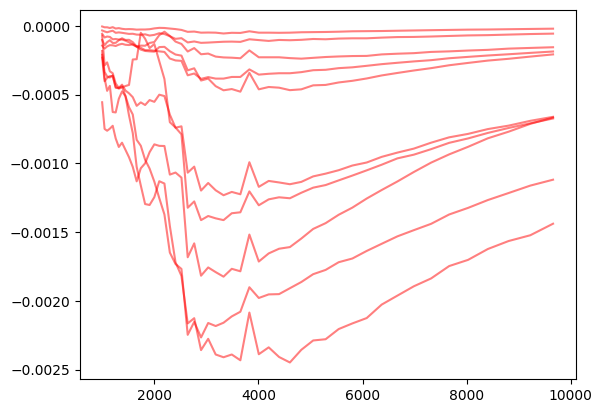

In [5]:
# Create a mask of bad curves
# First remove curves with NaNs or negative values
bad_mask = np.any(np.isnan(A_curves), axis=1) | np.any(A_curves <= 0, axis=1)
print(f'Removed {np.sum(bad_mask)} of {A_curves.shape[0]} curves with NaNs or non-positive values')
print(f'Percentage removed: {100 * np.sum(bad_mask) / A_curves.shape[0]:.2f}%')

# Let's plot those
A_bad = A_curves[bad_mask]
for i in range(min(10, A_bad.shape[0])):
    plt.plot(lam, A_bad[i], color='red', alpha=0.5)

-0.1265627849486331 223.16666666666669
-0.012142 13.929784
(50,)
Removed 100 of 26273 curves with max_diff > 0.5
Percentage removed: 0.38%


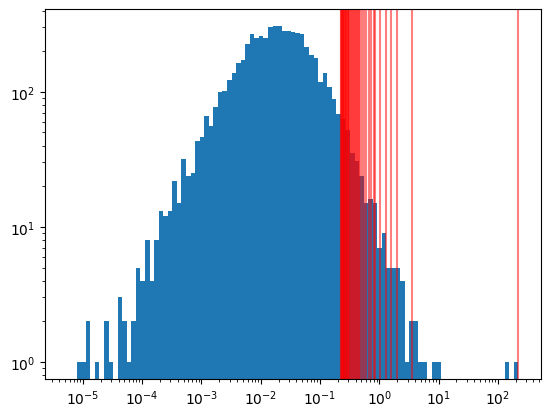

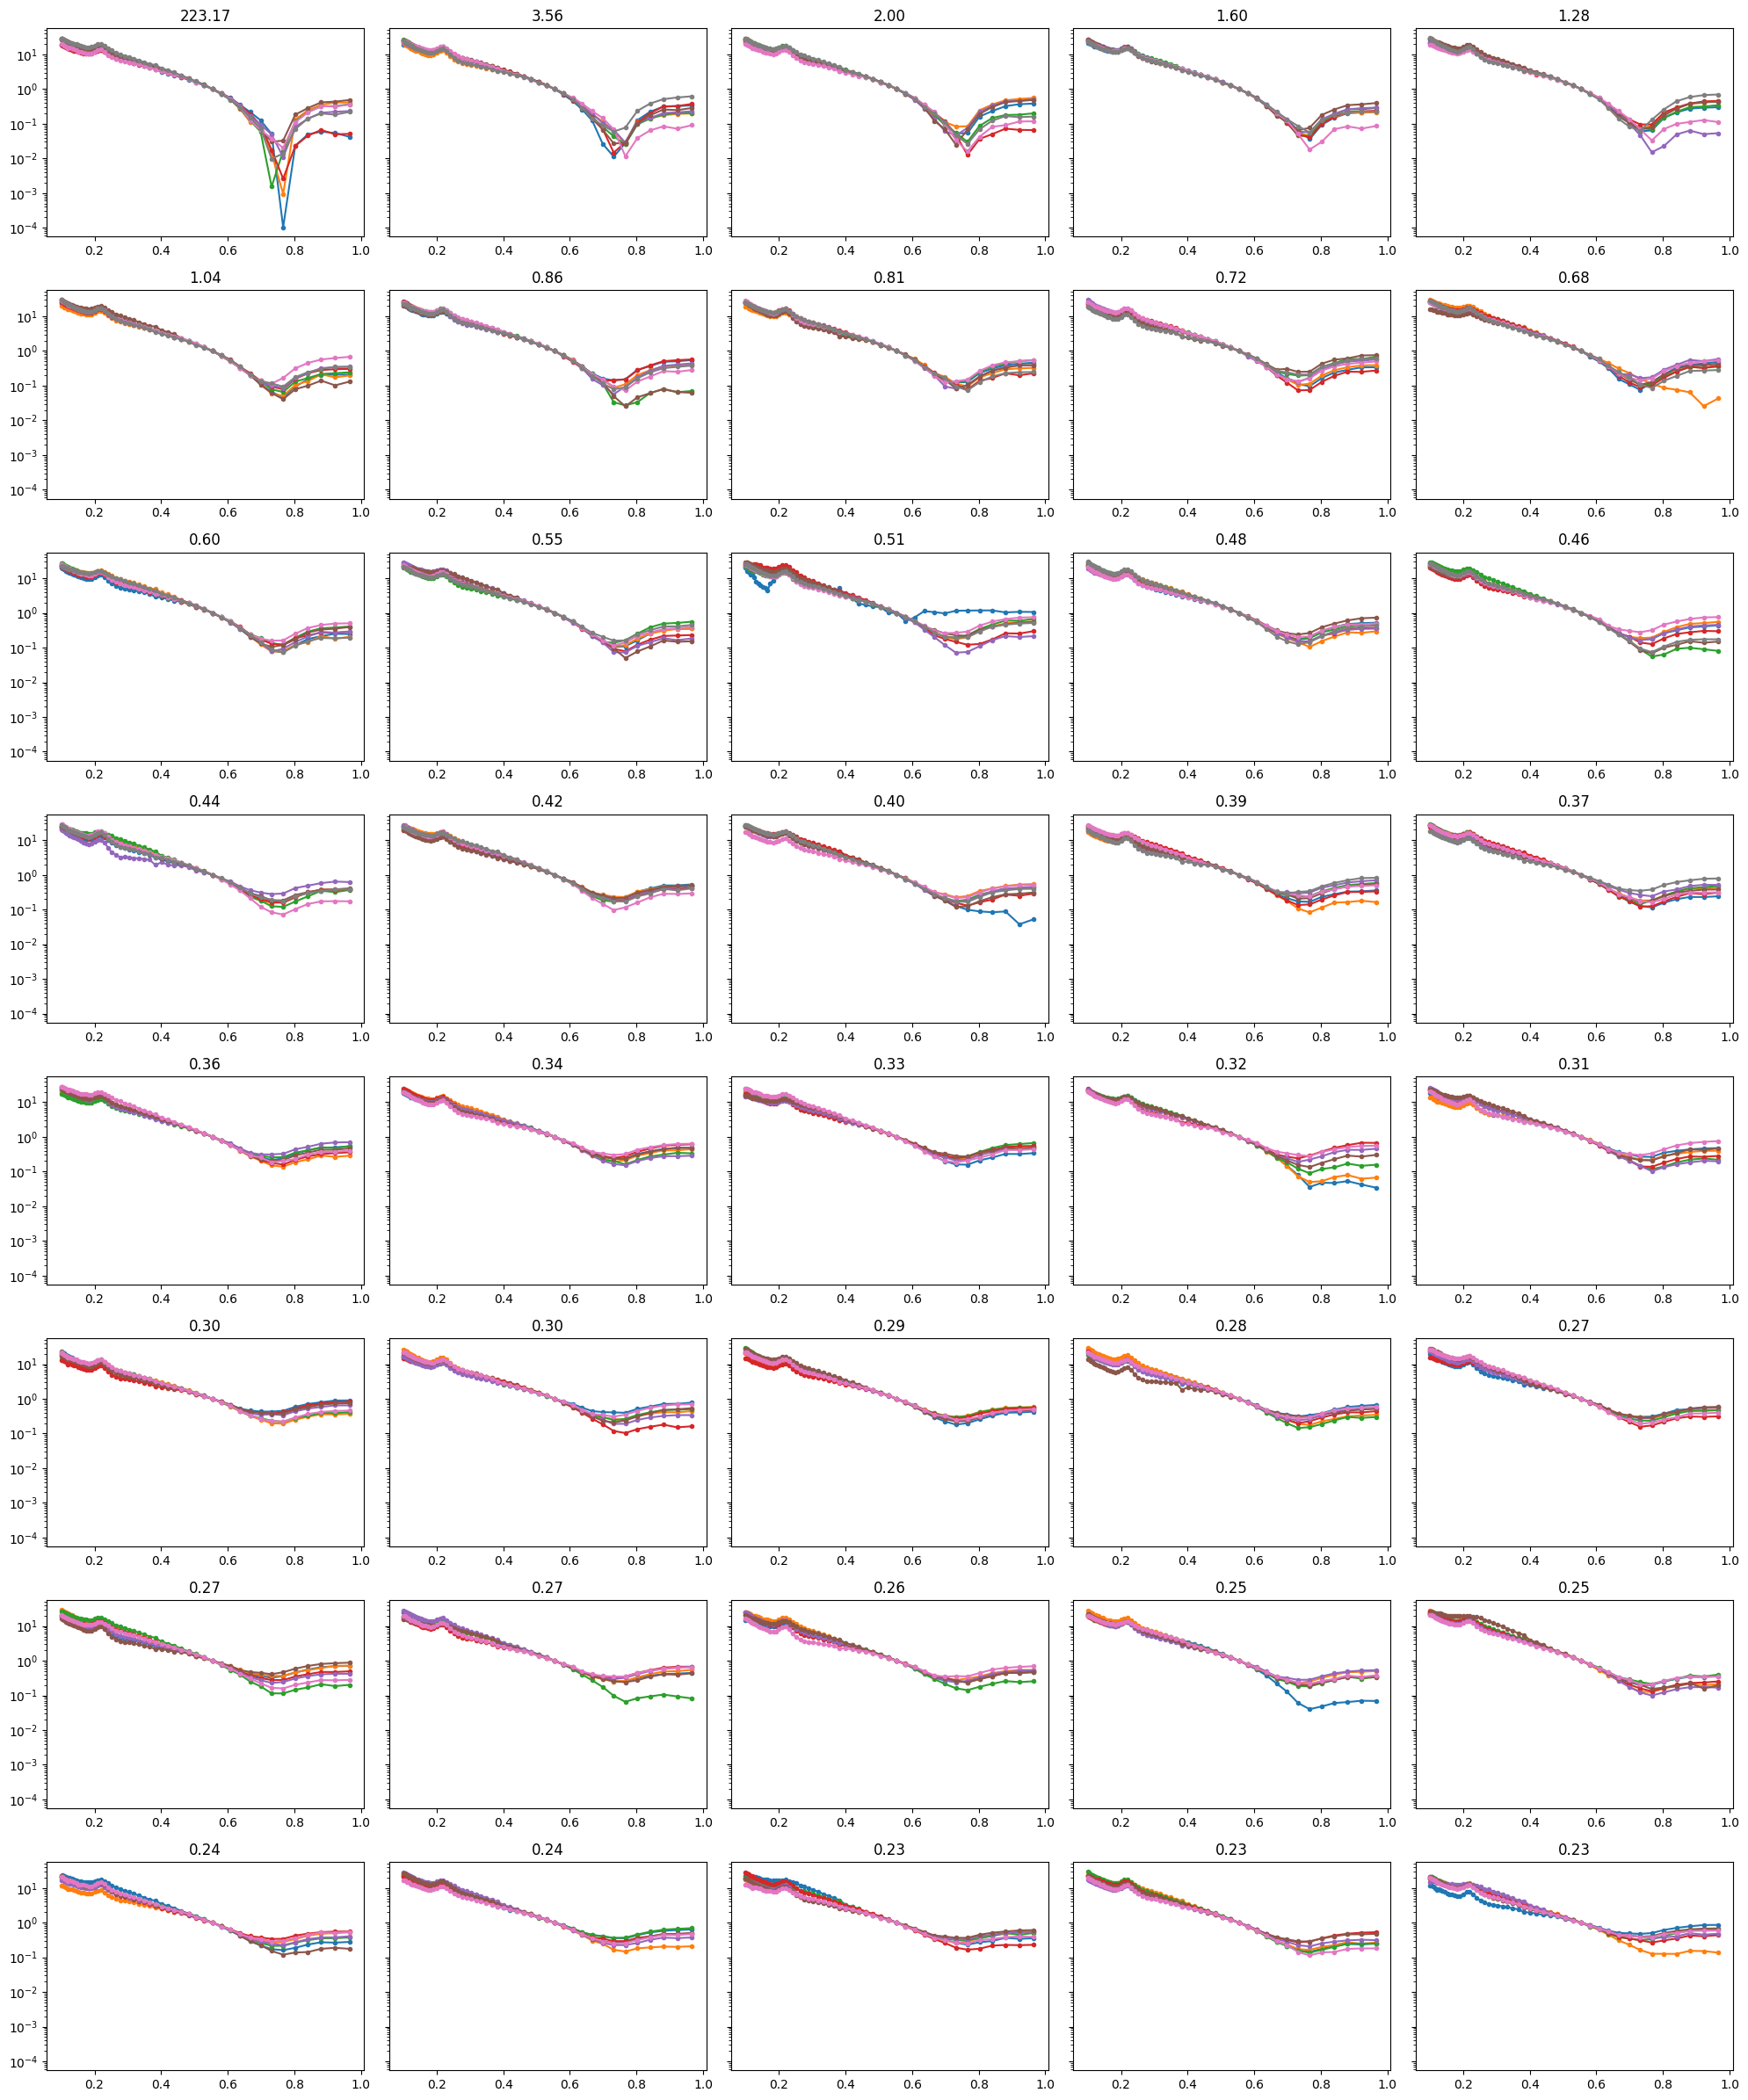

In [6]:
# Find out how many curves are not monotonically decreasing
# Of course, some noise could cause small non-monotonicities, so we first find the
# distribution of differences and set a threshold
lam_mask = lam > 5542
A_diff = np.diff(A_curves[~bad_mask][:, lam_mask], axis=1) / A_curves[~bad_mask][:, lam_mask][:, :-1]  # Relative difference between adjacent wavelengths
max_diff = np.max(A_diff, axis=1)  # Max difference between adjacent wavelengths for each curve

# Get lambda_v index
lv_idx = np.argmin(np.abs(lam - 5542))

# TO DO: Turn this into fractional difference (and remove those with zeros)
# Monotonically decreasing curves should have max_diff <= 0
m = max_diff > 0
print(max_diff.min(), max_diff.max())
bins = np.logspace(np.log10(max_diff[m].min()), np.log10(max_diff[m].max()), 100)
fig2, ax2 = plt.subplots()
ax2.hist(max_diff[m], bins=bins)
ax2.set_xscale('log')
ax2.set_yscale('log')

print(A_curves.min(), A_curves.max())

idx = np.argsort(-max_diff)
fig, axs = plt.subplots(8, 5, figsize=(20, 24), sharey=True)
axs = axs.flatten()
use_idx = np.array_split(idx[:300], axs.shape[0])
# Plot some of the worst offenders
for ax, idx in zip(axs, use_idx):
    for i in range(len(idx)):
        ax.plot(lam / 10_000, A_curves[~bad_mask][idx[i]] / A_curves[~bad_mask][idx[i]][lv_idx], label=f'Max diff: {max_diff[idx[i]]:.3f}', marker='.')
    ax.set_yscale('log')
    ax.set_title('%.2f'%max_diff[idx[0]])
    ax2.axvline(max_diff[idx[0]], color='red', alpha=0.5)
print(A_curves[~bad_mask][idx[i]].shape)
fig.tight_layout()

# Chosen cut is at 0.5 - print how many curves are removed by this cut
cut_mask = max_diff > 0.5
print(f'Removed {np.sum(cut_mask)} of {A_curves.shape[0]} curves with max_diff > 0.5')
print(f'Percentage removed: {100 * np.sum(cut_mask) / A_curves.shape[0]:.2f}%')

# Small wavelength check

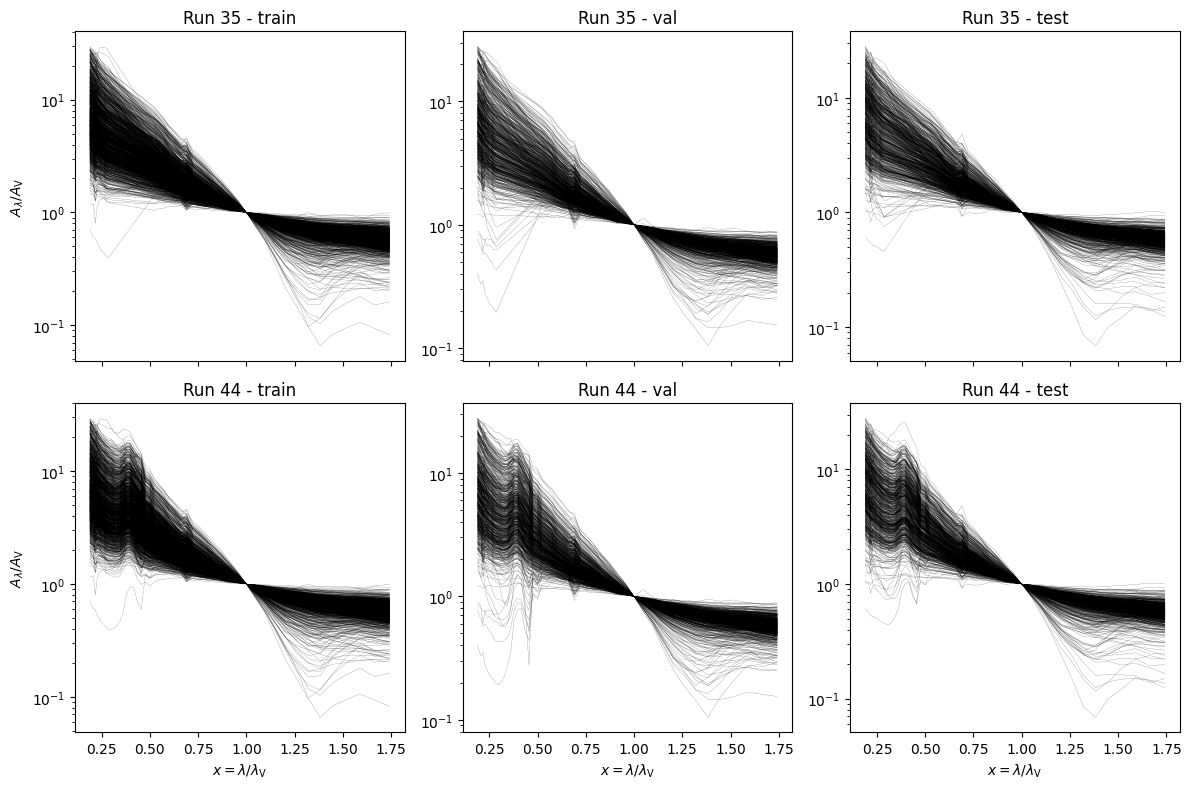

In [25]:
all_run_num = [35, 44]

fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True)

for i, run_num in enumerate(all_run_num):

    for j, name in enumerate(['train', 'val', 'test']):
        fname = f'../data/iob_data_{run_num}/iob_{name}_data.txt'
        df = pd.read_csv(fname, sep=r'\s+')

        # Group by galaxy id and los
        grouped = df.groupby(['galaxy_id', 'los'])
        
        # Collect all line segments
        lines = []
        for (galaxy_id, los), group in grouped:
            lam = group['lam'].values
            A = group['A'].values
            # Stack as (N, 2) array for each line segment
            lines.append(np.column_stack([lam, A]))
        
        # Save the (galaxy_id, los) to file
        with open(f'run_{run_num}_{name}_id_los.txt', 'w') as f:
            f.write('galaxy_id los\n')
            for (galaxy_id, los), group in grouped:
                lam = group['lam'].values
                A = group['A'].values
                f.write(f'{int(galaxy_id)} {int(los)}\n')

        # Plot all lines at once using LineCollection
        lc = LineCollection(lines, colors='k', linewidths=0.1)
        axs[i,j].add_collection(lc)
        
        # Set axis scales and limits
        axs[i,j].set_yscale('log')
        axs[i,j].autoscale()
        axs[i,j].set_title(f'Run {run_num} - {name}')


for i in range(axs.shape[0]):
    axs[i,0].set_ylabel(r'$A_\lambda / A_{\rm V}$')
for j in range(axs.shape[1]):
    axs[-1,j].set_xlabel(r'$x = \lambda / \lambda_{\rm V}$')

fig.align_labels()
fig.tight_layout()
fig.savefig('training_data_curves.png', bbox_inches='tight', dpi=300)